<a href="https://colab.research.google.com/github/salimdo2004/Pr-diction-des-Maladies-Cardiaques-par-Machine-Learning-/blob/main/Heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns
sns.set_style("whitegrid")

In [ ]:
# 2. Load data
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
#afficher  les colonnes
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
#information  : columns-type...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
 14  Cluster   1025 non-null   int32  
dtypes: float64(1), int32(1), int64(13)
memory usage: 116.2 KB


In [ ]:
df.dropna(inplace=True)

In [ ]:
#Nombre des lignes et des colonnes
df.shape

(1025, 14)

In [ ]:
#Vérifier les valeurs manquantes
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.fillna(df.mean(), inplace=True)

Statistiques descriptives

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


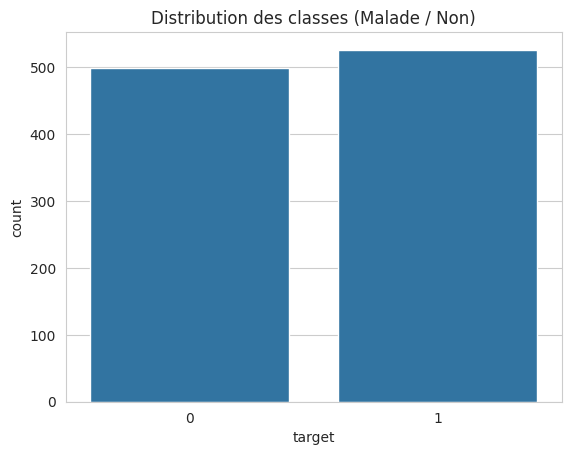

In [ ]:
#Distribution de la variable cible (malade ou non)
import matplotlib.pyplot as plt
sns.countplot(x='target', data=df)
plt.title("Distribution des classes (Malade / Non)")
plt.show()

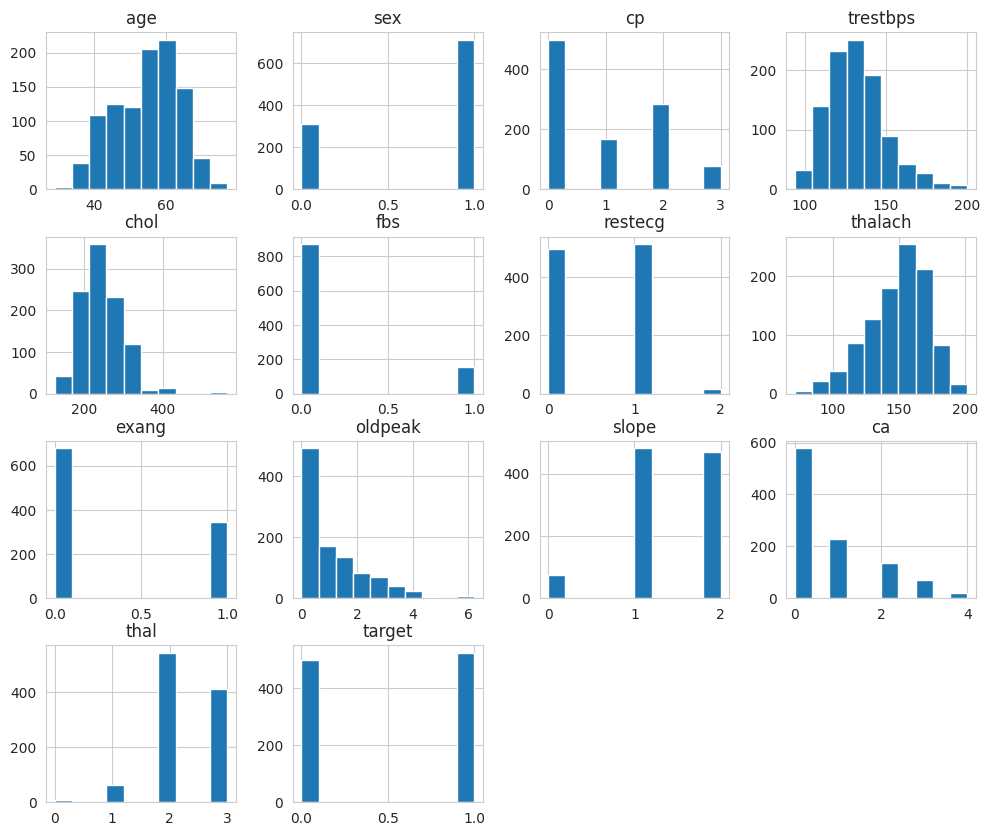

In [ ]:
df.hist(figsize=(12,10))
plt.show()

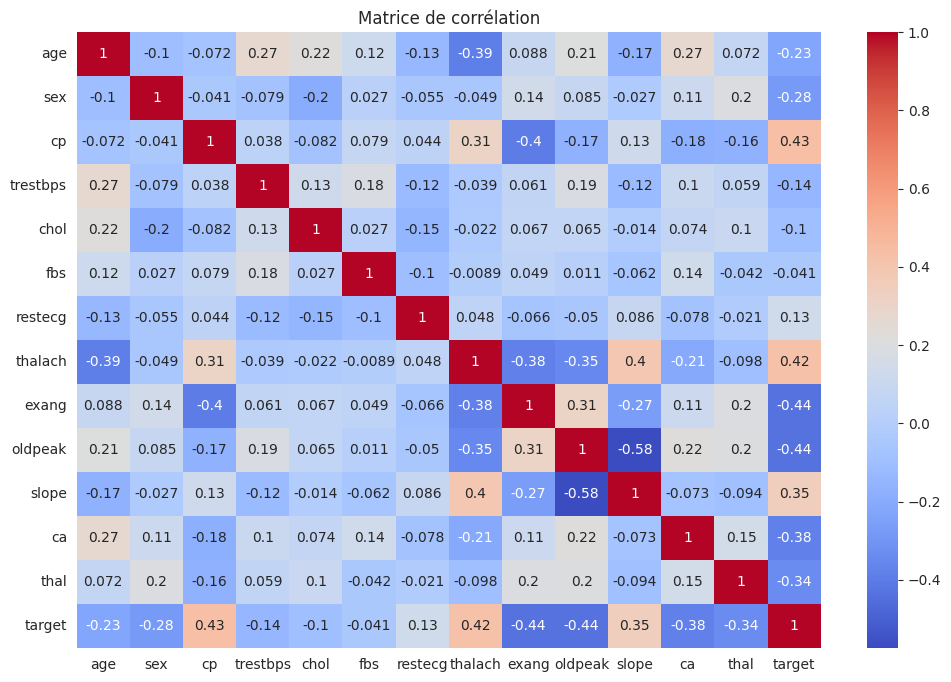

In [ ]:
#Corrélation entre les variables
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

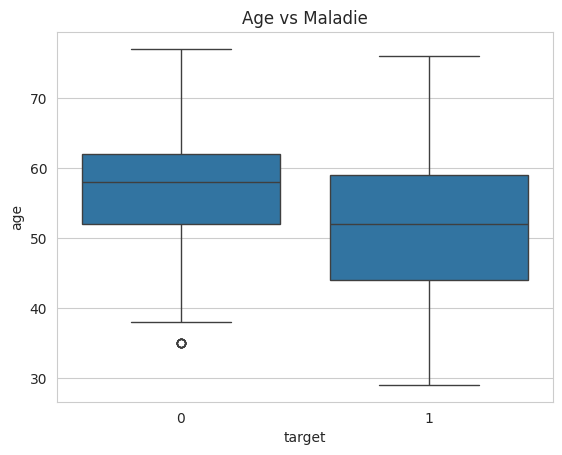

In [ ]:
#Analyse par rapport à la maladie
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Maladie")
plt.show()

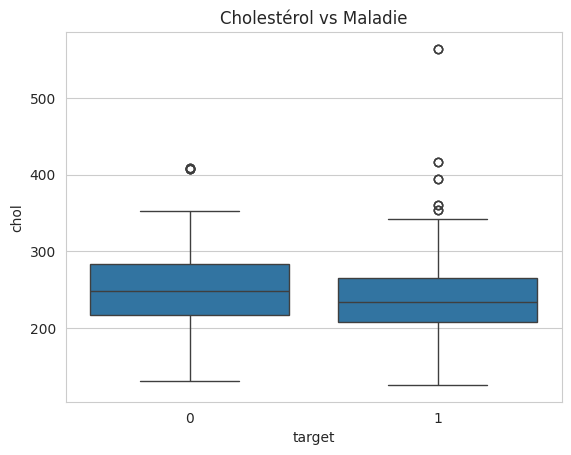

In [ ]:
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholestérol vs Maladie")
plt.show()

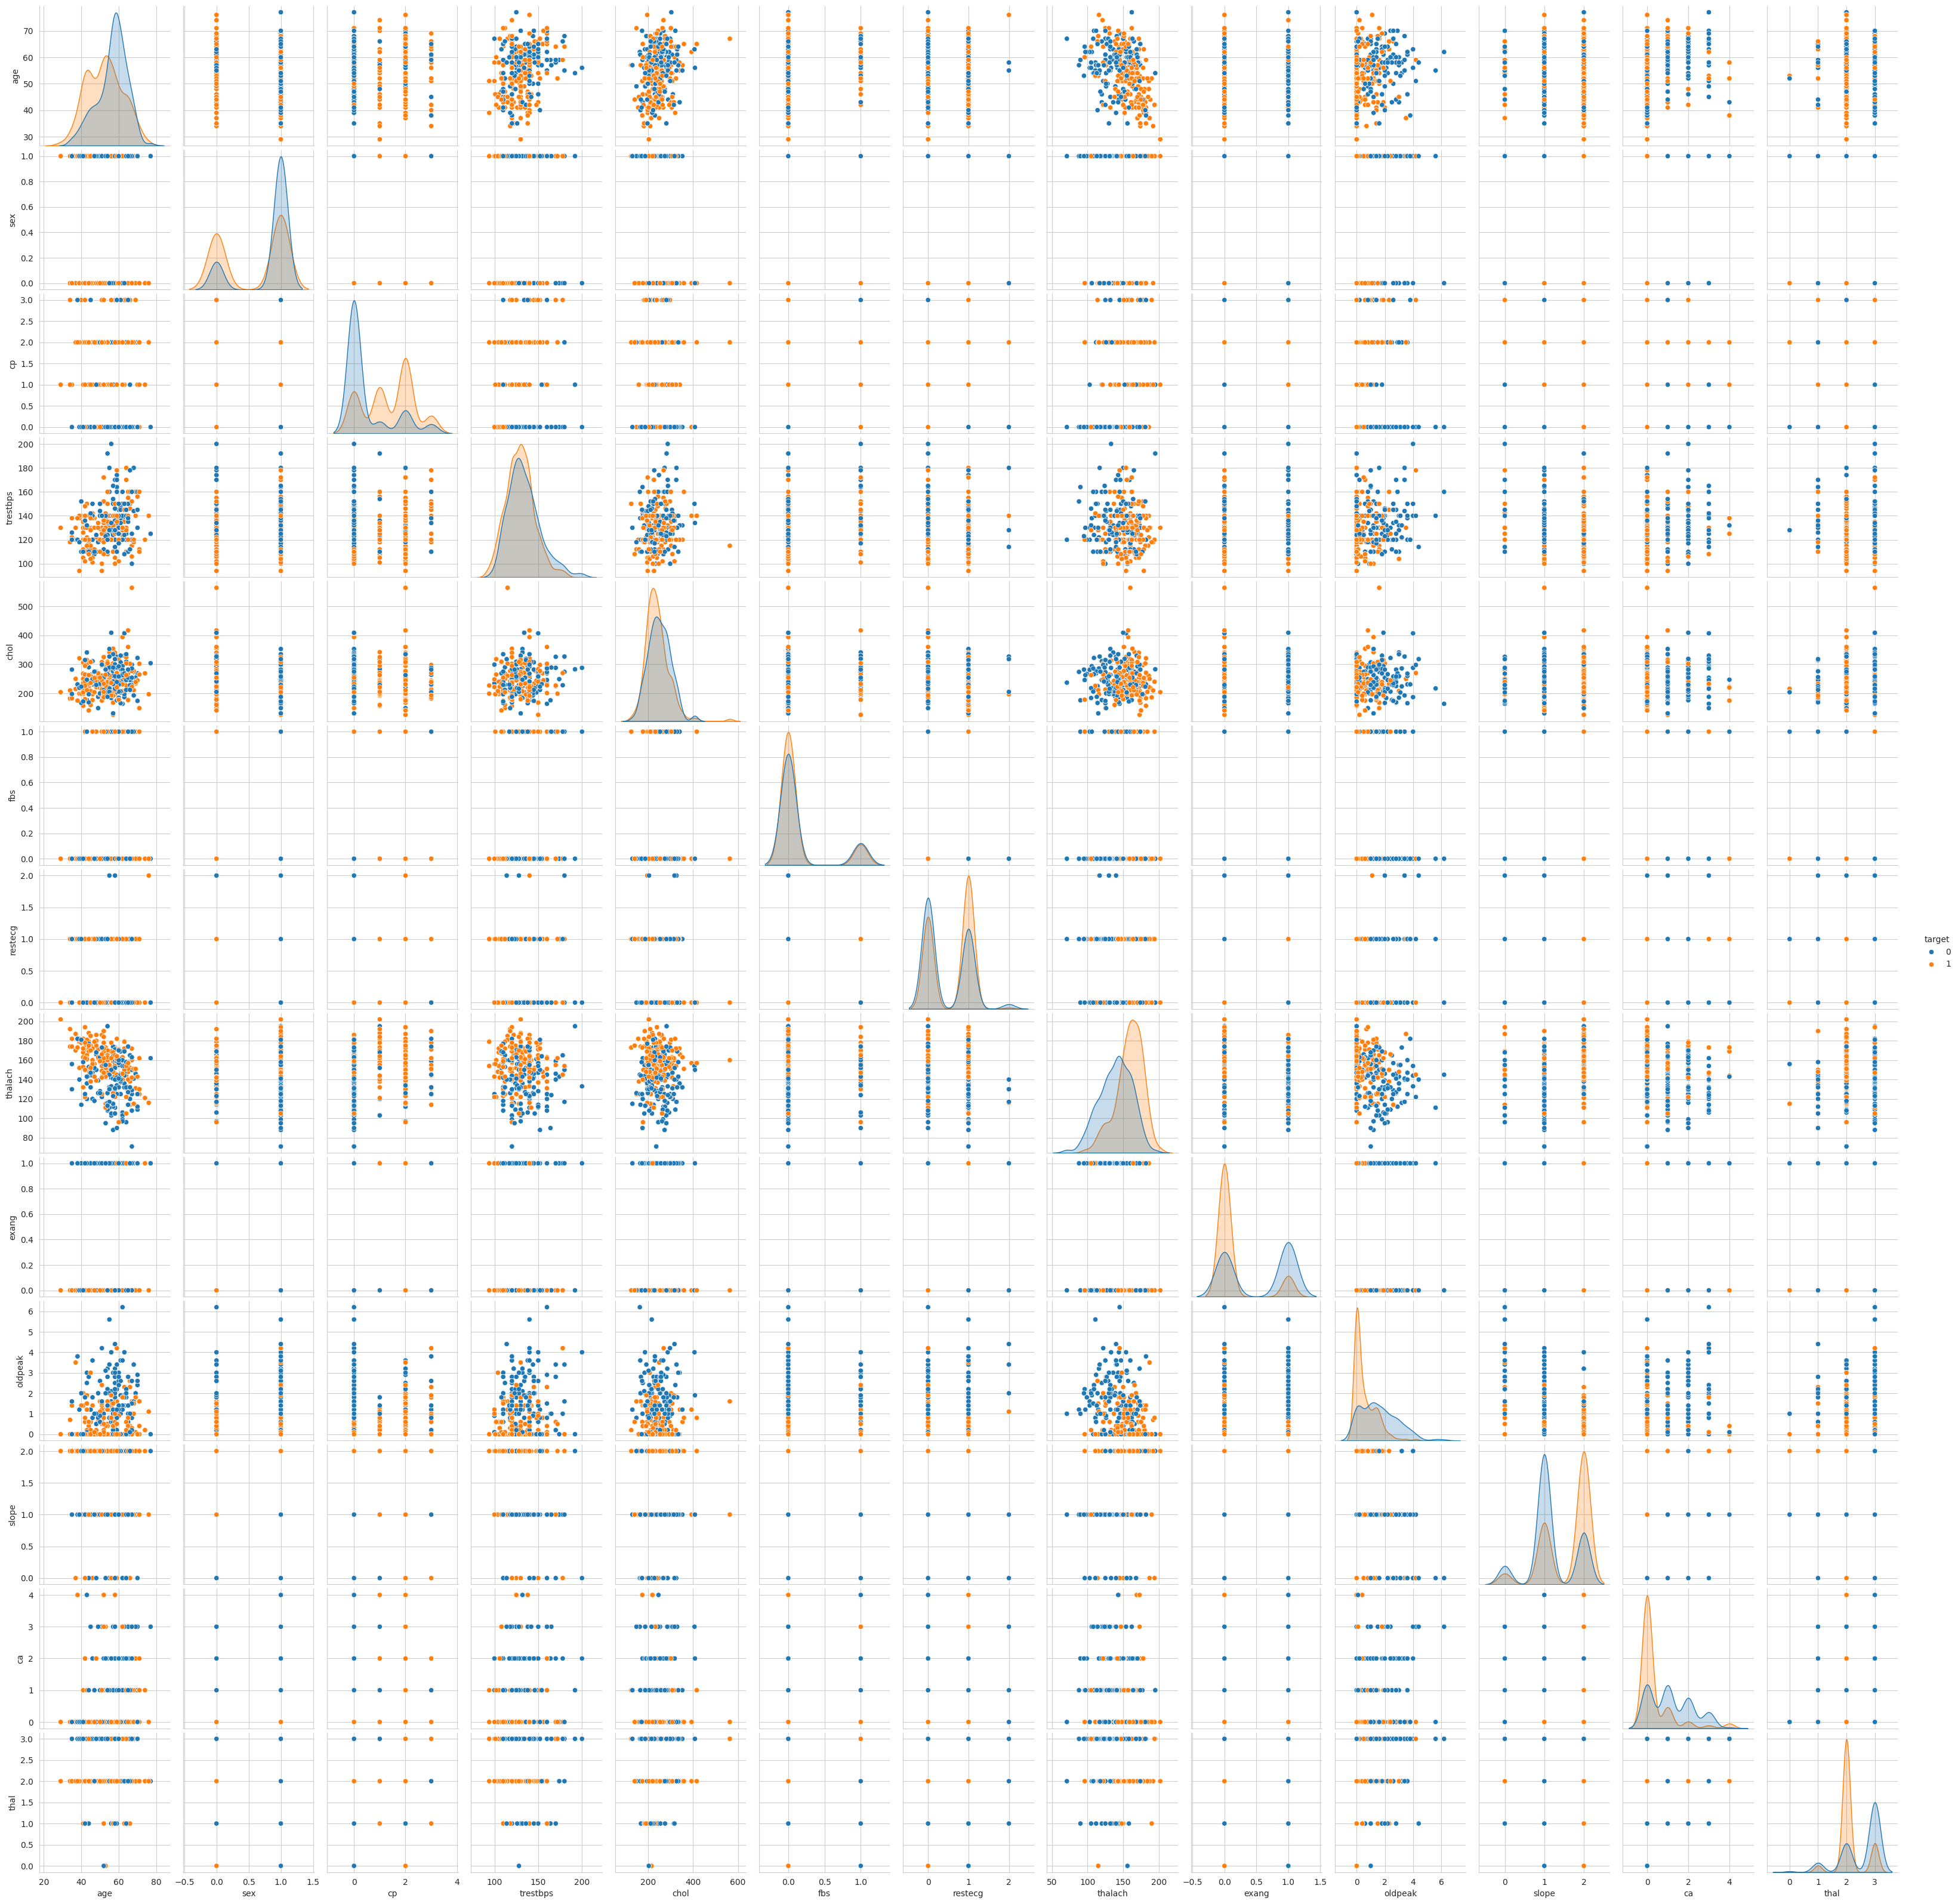

In [ ]:
#Pairplot
sns.pairplot(df, hue='target')
plt.show()

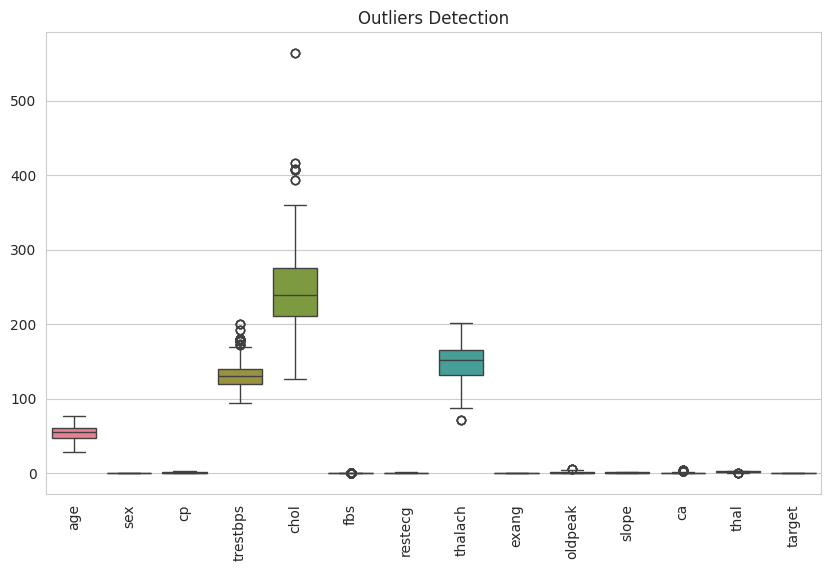

In [ ]:
#Détection des outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outliers Detection")
plt.show()

In [ ]:
# Features / Target
X = df.drop("target", axis=1)
y = df["target"]

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_
centers = kmeans.cluster_centers_

Visualisation avec PCA

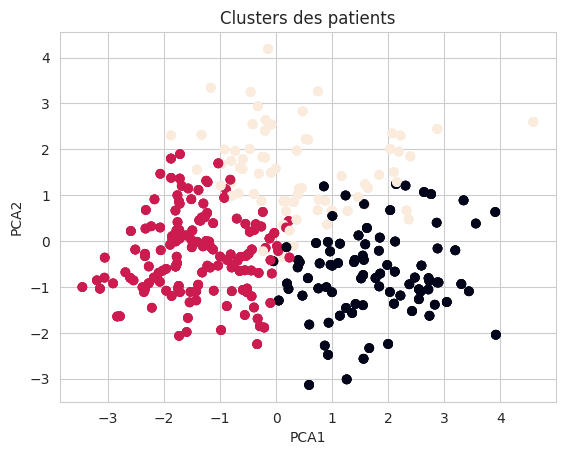

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Clusters des patients")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [ ]:
#Cluster 0 → patients sains
#Cluster 1 → patients à risque
#Cluster 2 → patients critiques
df.groupby("Cluster").mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
Cluster,,,,,,,,,,,,,,
0,57.320635,0.857143,0.200000,129.323810,248.774603,0.098413,0.441270,129.431746,0.800000,1.830794,1.050794,1.193651,2.631746,0.120635
1,49.308824,0.686975,1.178571,125.138655,235.491597,0.037815,0.644958,163.663866,0.094538,0.448529,1.691176,0.411765,2.218487,0.762605
2,60.974359,0.495726,1.461538,147.858974,263.641026,0.444444,0.414530,146.012821,0.205128,1.316667,1.213675,0.858974,2.123932,0.534188


SUPERVISÉ (Prédiction)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Random Forest

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel="linear", probability=True)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8146341463414634


Matrice de confusion

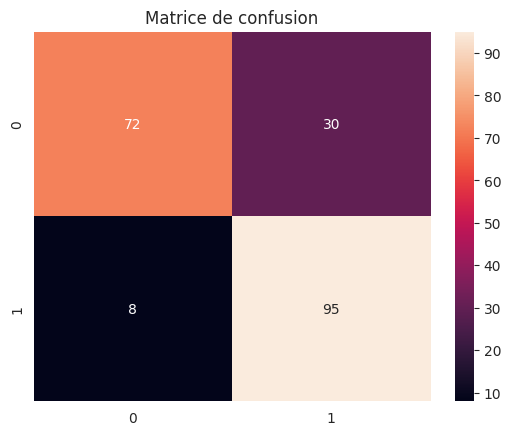

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matrice de confusion")
plt.show()

Importance des features

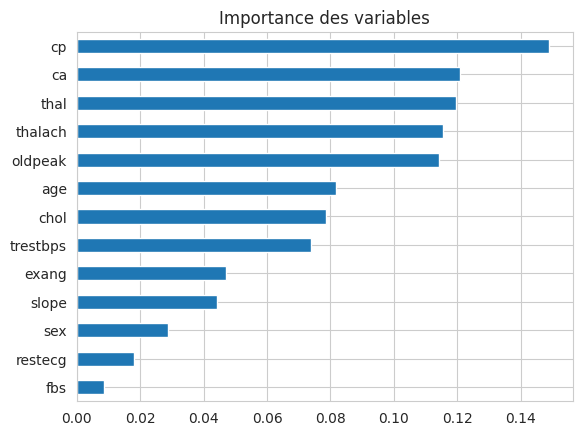

In [ ]:
importances = model.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)
feat_importance.sort_values().plot(kind="barh")
plt.title("Importance des variables")
plt.show()

In [ ]:
print("Poids (w):", svm_model.coef_)
print("Biais (b):", svm_model.intercept_)

Poids (w): [[ 0.01994392 -0.52288643  0.67651506 -0.23863175 -0.22973797  0.04328932
   0.05536622  0.38842528 -0.23807408 -0.584445    0.25733626 -0.51573364
  -0.53929044]]
Biais (b): [0.06480557]


Sauvegarder le modèle

In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))